In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

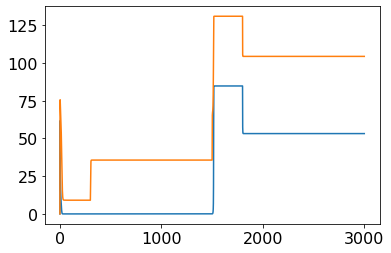

[[9.9409e-03 3.5642e+01]
 [5.3253e+01 1.0443e+02]]


In [3]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] * 1.01
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1] * 1.01

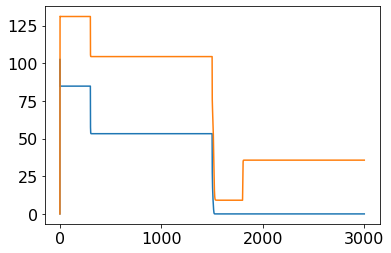

In [4]:
aln.params['duration'] = 3000.
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.99
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-2] * 0.99  

In [5]:
dur = 15.
dur_pre = 5.
dur_post = 5.
aln.params.duration = dur

control0 = aln.getZeroControl()

# set high state rates as target
target_lh = aln.getZeroTarget()
target_lh[:,0,:] = steady_rates[1,0]
target_lh[:,1,:] = steady_rates[1,1] 

max_it = 5
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 10.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

alg = "A1"
#alg = "A2"

In [6]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]

## B) State switching from low to high
- no adaptation (-> bistability)
- no delay
- max control current 1nA
- w_p = w_e = w_s = 1

In [8]:
cost.setParams(1.0, 1.0, 1.0)
max_cntrl = 1. * 5.

setinitvars(low_state_vars)
max_it = 100
alg = "A1"
case = "B"

aln.params.duration = dur
control0 = aln.getZeroControl()

bestControlA_A1, bestStateA_A1, costA_A1, runtimeA_A1 = aln.A1(control0, target_lh, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  57085.07321848622
RUN  1 , total integrated cost =  18187.38625598059
RUN  2 , total integrated cost =  10711.638430235444
RUN  3 , total integrated cost =  9512.74076168752
RUN  4 , total integrated cost =  8540.003059276287
RUN  5 , total integrated cost =  8047.0724754169105
RUN  6 , total integrated cost =  7509.7238539520895
RUN  7 , total integrated cost =  7135.913155723374
RUN  8 , total integrated cost =  6706.142930360443
RUN  9 , total integrated cost =  6362.573907051336
RUN  10 , total integrated cost =  6090.46173320294
RUN  11 , total integrated cost =  5851.102468119857
RUN  12 , total integrated cost =  5581.028450958712
RUN  13 , total integrated cost =  5384.735137137778
RUN  14 , total integrated cost =  5255.049588597704
RUN  15 , total integrated cost =  5130.584426733152
RUN  16 , total integrated cost =  5013.292760404357
RUN  17 , total integrated cost =  4898.04389865997
RUN  18 , total integrated cost =  4781.

ERROR:root:Problem in initial value trasfer


RUN  96 , total integrated cost =  4292.220199717644
RUN  97 , total integrated cost =  4292.218115948769
RUN  98 , total integrated cost =  4292.216095682992
RUN  99 , total integrated cost =  4292.214111562116
RUN  100 , total integrated cost =  4292.212183445713
Improved over  100  iterations by  92.48102535137726  percent.
Problem in initial value trasfer:  Vmean_exc -56.70421388415996 -56.70421389697763


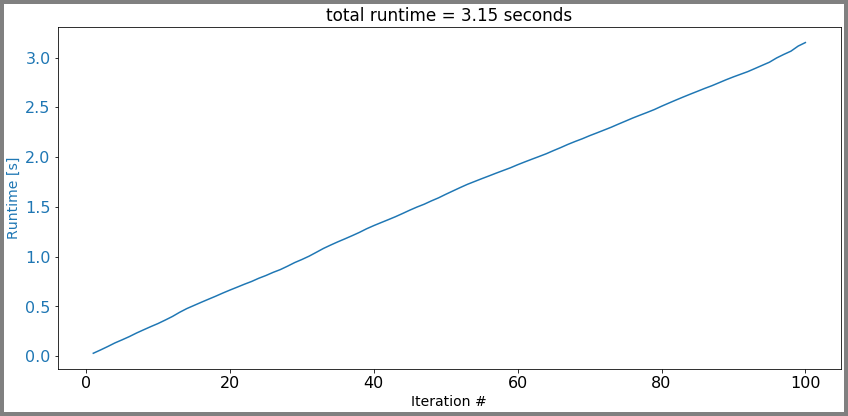

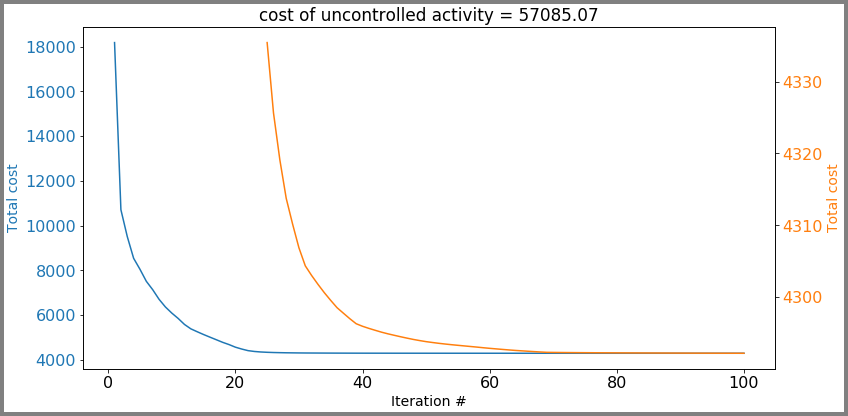

In [9]:
plotFunc.plot_runtime(runtimeA_A1, path, str("p1_e1_s1_u1nA_LowHigh_runtime_" + case + "_" + alg) )
plotFunc.plot_convergence(costA_A1, path, str("p1_e1_s1_u1nA_LowHigh_cost_" + case + "_" + alg) )

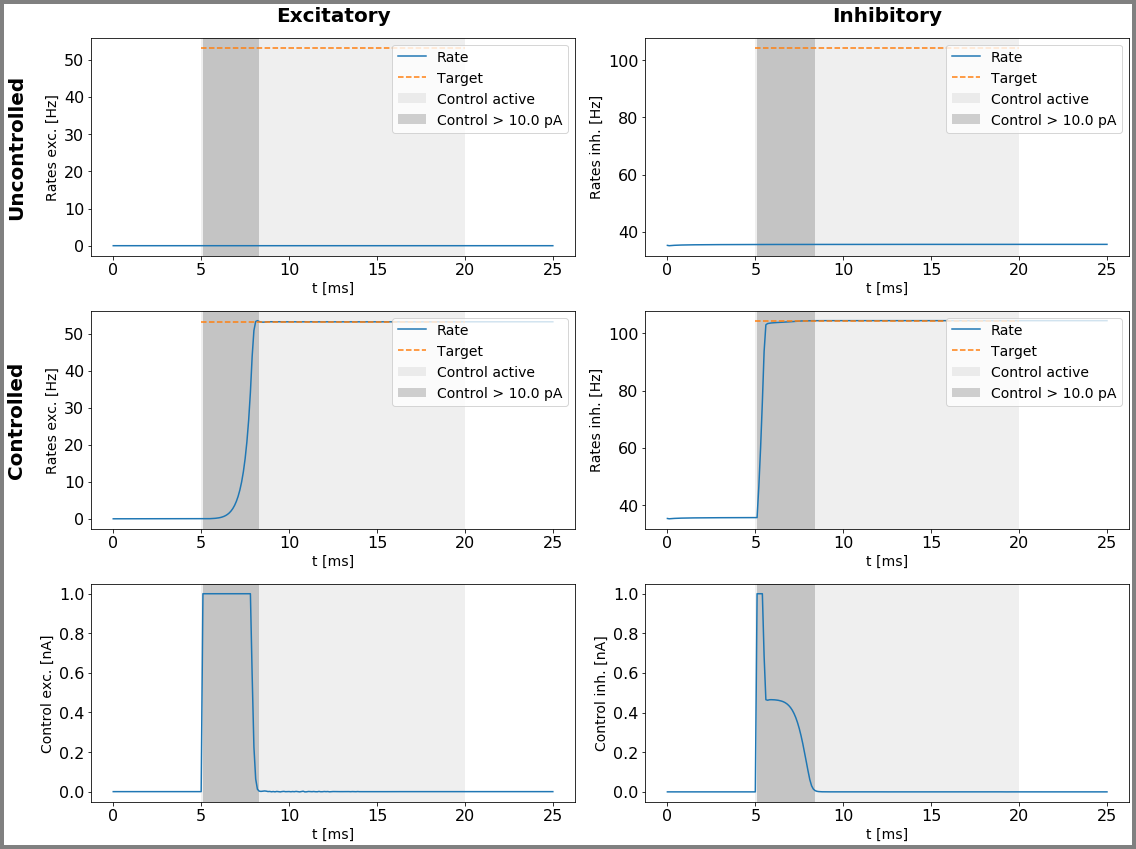

In [10]:
plotFunc.plot_control(aln, bestControlA_A1, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))

In [11]:
setinitvars(low_state_vars)
max_it = 40
alg = "A2"
case = "A"

aln.params.duration = dur
control0 = aln.getZeroControl()

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control0, target_lh,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

RUN  0 , total integrated cost:  57085.07321848622
RUN  1 , total integrated cost:  5030.2174031411505
RUN  2 , total integrated cost:  4694.752025503625
RUN  3 , total integrated cost:  4326.873713387499
RUN  4 , total integrated cost:  4309.020028410588
RUN  5 , total integrated cost:  4301.4605044446
RUN  6 , total integrated cost:  4296.613187007567
RUN  7 , total integrated cost:  4294.380667665958
RUN  8 , total integrated cost:  4293.132159745918
RUN  9 , total integrated cost:  4292.510889808501
test control change smaller than tolerance, return zero step
test control change smaller than tolerance, return zero step
RUN  10 , total integrated cost:  4292.325471521413
RUN  11 , total integrated cost:  4292.193132046649
test control change smaller than tolerance, return zero step
RUN  12 , total integrated cost:  4292.13698978903
RUN  13 , total integrated cost:  4292.122973444423
test control change smaller than tolerance, return zero step
RUN  14 , total integrated cost:  4292.1

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost:  4292.110635352322
Improved over  40  iterations by  93  percent.
Problem in initial value trasfer:  Vmean_exc -56.70421486451063 -56.70421478916613


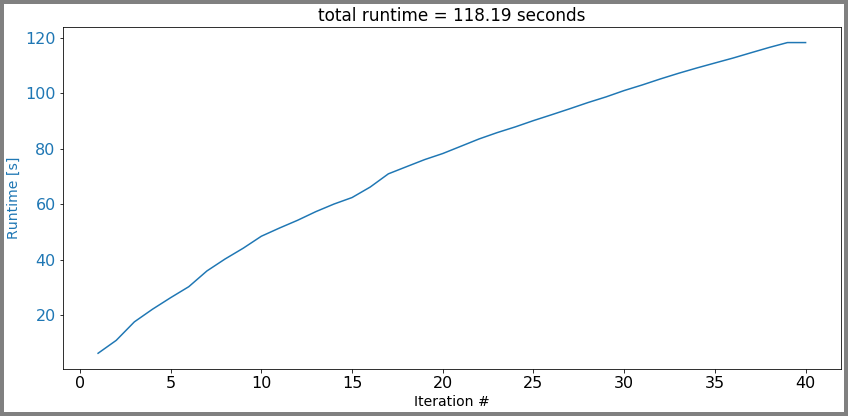

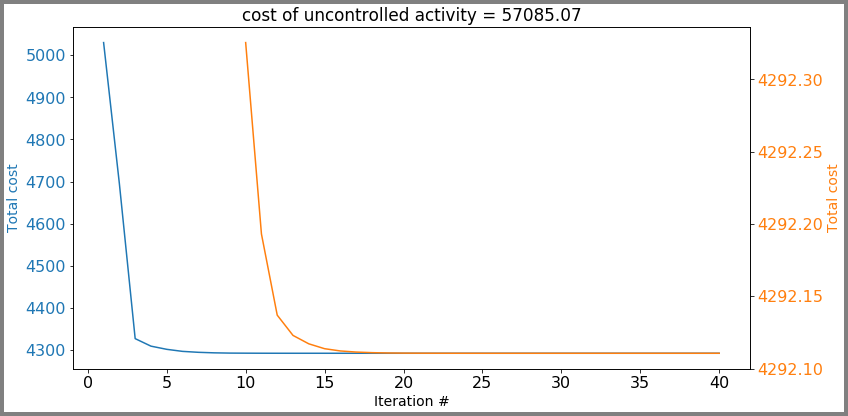

In [12]:
plotFunc.plot_runtime(runtimeA_A2, path, str("p1_e1_s1_u1nA_LowHigh_runtime_" + case + "_" + alg) )
plotFunc.plot_convergence(costA_A2, path, str("p1_e1_s1_u1nA_LowHigh_cost_" + case + "_" + alg) )

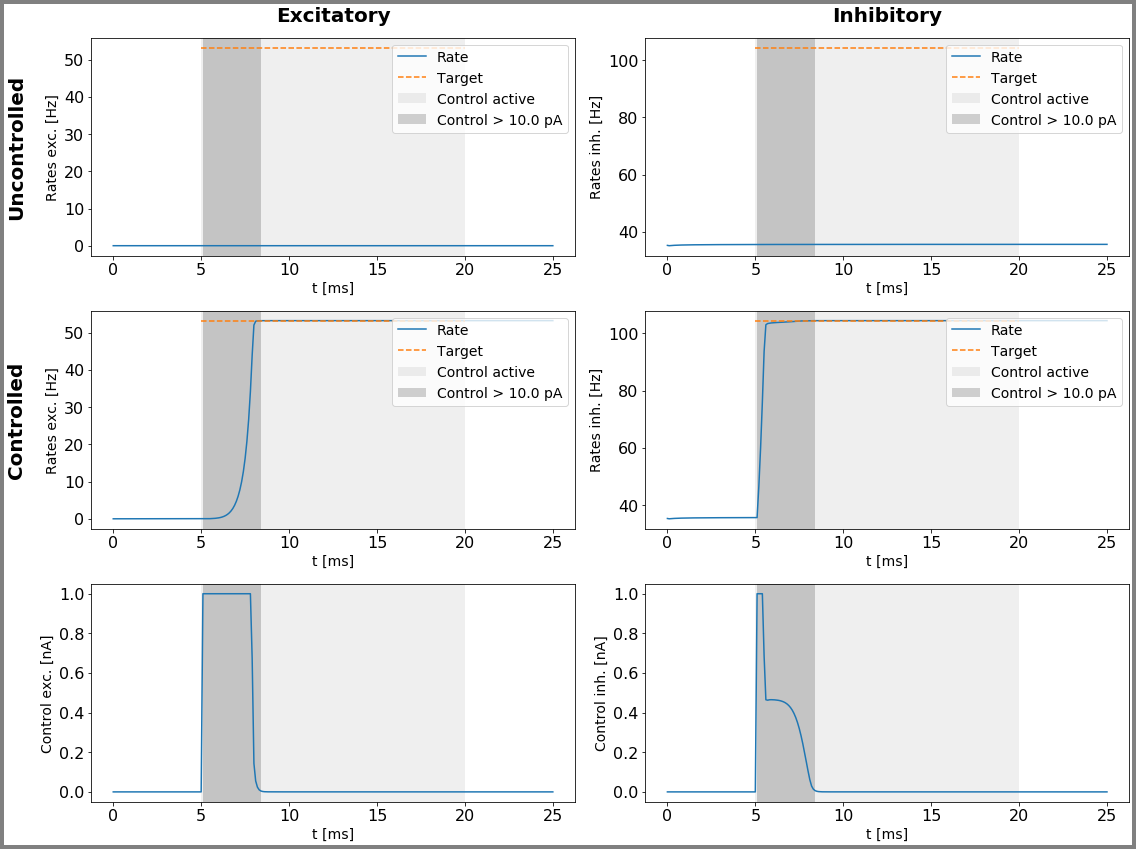

In [13]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))

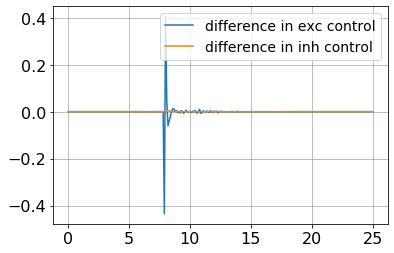

In [15]:
diff = bestControlA_A1 - bestControlA_A2

t = np.arange(0,dur + dur_pre + dur_post + aln.params.dt, aln.params.dt)
plt.plot(t, diff[0,0,:], label="difference in exc control")
plt.plot(t, diff[0,1,:], label="difference in inh control")
plt.grid()
plt.legend()
plt.show()